In [ ]:
# === Colab bootstrap (no-op outside Colab) ===========================
# Clones the repo, installs minimal deps, mounts Google Drive, and
# symlinks heavy assets from Drive into the paths the notebook uses.
# See COLAB_SETUP.md for details.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, subprocess, sys
    REPO = "/content/INF8225_Projet"
    if not os.path.isdir(REPO):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/Azcatchi17/INF8225_Projet.git", REPO,
        ])
    if os.getcwd() != REPO:
        os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    from colab.setup import setup
    setup()
# ======================================================================


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
[nltk_data] Downloading package punkt_tab to /home/paulb/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/paulb/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-package

Loads checkpoint by local backend from path: work_dirs/polyp_config/best_coco_bbox_mAP_epoch_2.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

noun_phrases: ['polyp']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


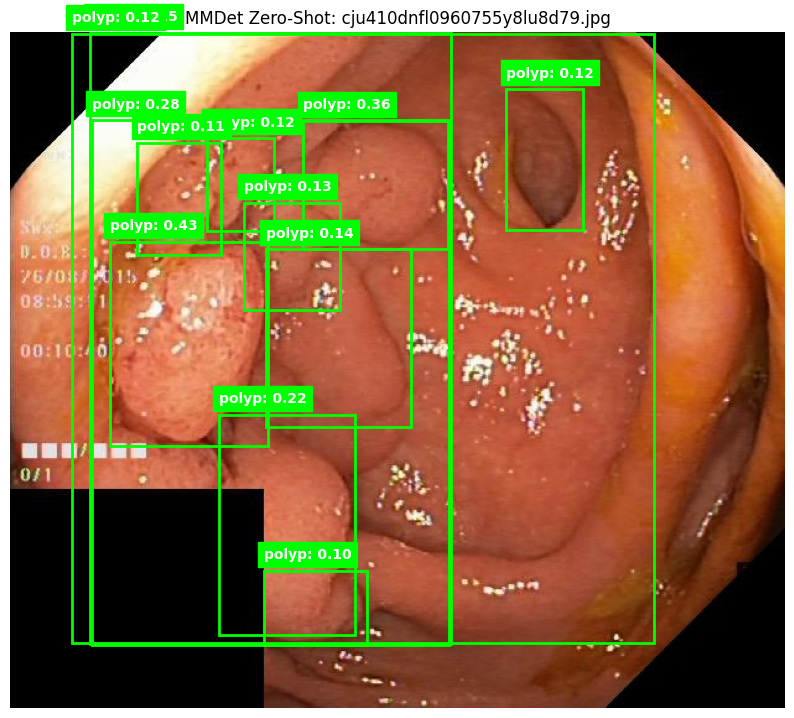

In [1]:
import torch
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
import mmcv
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random
import glob

import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# 1. Initialisation
# register_all_modules est crucial pour que MMDetection trouve GroundingDINO
register_all_modules()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Chemins vers les fichiers téléchargés via mim
config_file = 'work_dirs/polyp_config/polyp_config.py'
checkpoint_file = 'work_dirs/polyp_config/best_coco_bbox_mAP_epoch_2.pth'

# Chargement du modèle
model = init_detector(config_file, checkpoint_file, device=device)

def test_mmdet_grounding_dino(image_path, text_prompt="polyp"):
    # MMDetection 3.x attend souvent le point final pour Grounding DINO
    if not text_prompt.endswith('.'):
        text_prompt += '.'
    
    # Inférence
    # Pour Grounding DINO, on passe le texte via l'argument text_prompt
    result = inference_detector(model, image_path, text_prompt=text_prompt)
    
    # Extraction des résultats (format DetDataSample)
    pred_instances = result.pred_instances
    
    # Filtrage par seuil (threshold)
    # On garde les scores > 0.3
    scores = pred_instances.scores.cpu().numpy()
    bboxes = pred_instances.bboxes.cpu().numpy()
    labels = pred_instances.labels.cpu().numpy() # Note: DINO renvoie souvent le même label pour le texte
    
    mask = scores > 0.1
    valid_boxes = bboxes[mask]
    valid_scores = scores[mask]

    # Visualisation
    image = mmcv.imread(image_path)
    image = mmcv.rgb2bgr(image) # MMDetection travaille souvent en BGR en interne
    image = Image.fromarray(image)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)

    for score, box in zip(valid_scores, valid_boxes):
        # Format MMDetection : [xmin, ymin, xmax, ymax]
        rect = patches.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(box[0], box[1]-10, f"polyp: {score:.2f}", color='white', 
                backgroundcolor='lime', fontsize=10, fontweight='bold')

    plt.axis('off')
    plt.title(f"MMDet Zero-Shot: {os.path.basename(image_path)}")
    plt.show()

# Test aléatoire
# img_dir = "data/Kvasir-SEG/images"
# image_paths = glob.glob(os.path.join(img_dir, "*.jpg"))
# if image_paths:
#     test_mmdet_grounding_dino(random.choice(image_paths))

test_mmdet_grounding_dino("data/Kvasir-SEG/images/cju410dnfl0960755y8lu8d79.jpg")

[nltk_data] Downloading package punkt_tab to /home/paulb/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/paulb/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Loads checkpoint by local backend from path: work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

noun_phrases: ['tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


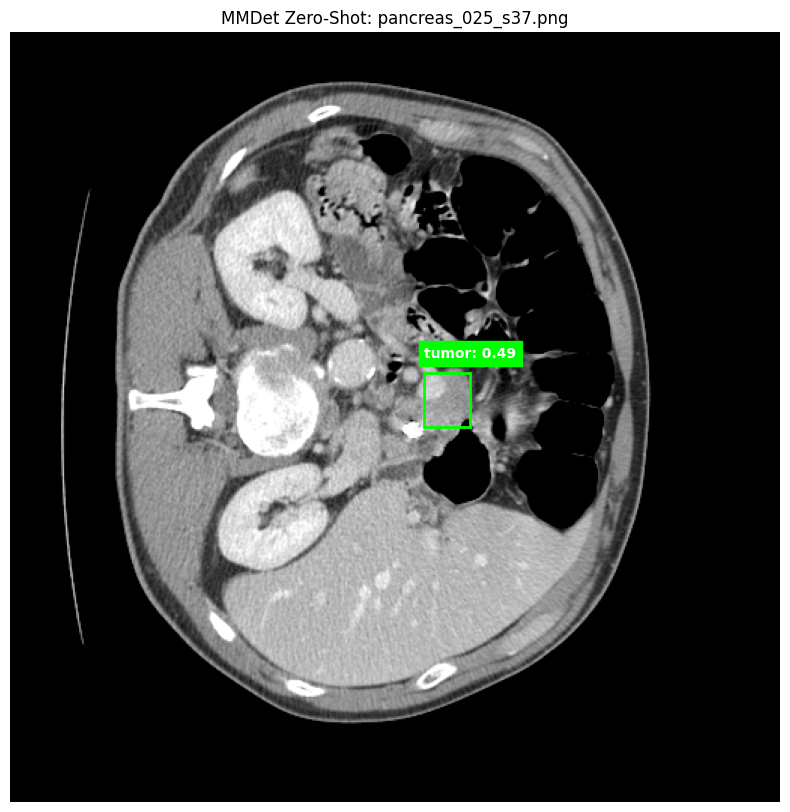

In [2]:
import torch
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
import mmcv
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random
import glob

import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# 1. Initialisation
# register_all_modules est crucial pour que MMDetection trouve GroundingDINO
register_all_modules()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Chemins vers les fichiers téléchargés via mim
config_file = "tumor_config_v3.py"
checkpoint_file = "work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth"

# Chargement du modèle
model = init_detector(config_file, checkpoint_file, device=device)

def test_mmdet_grounding_dino(image_path, text_prompt="tumor"):
    # MMDetection 3.x attend souvent le point final pour Grounding DINO
    if not text_prompt.endswith('.'):
        text_prompt += '.'
    
    # Inférence
    # Pour Grounding DINO, on passe le texte via l'argument text_prompt
    result = inference_detector(model, image_path, text_prompt=text_prompt)
    
    # Extraction des résultats (format DetDataSample)
    pred_instances = result.pred_instances
    
    # Filtrage par seuil (threshold)
    # On garde les scores > 0.3
    scores = pred_instances.scores.cpu().numpy()
    bboxes = pred_instances.bboxes.cpu().numpy()
    labels = pred_instances.labels.cpu().numpy() # Note: DINO renvoie souvent le même label pour le texte
    
    mask = scores > 0.2
    valid_boxes = bboxes[mask]
    valid_scores = scores[mask]

    # Visualisation
    image = mmcv.imread(image_path)
    image = mmcv.rgb2bgr(image) # MMDetection travaille souvent en BGR en interne
    image = Image.fromarray(image)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)

    for score, box in zip(valid_scores, valid_boxes):
        # Format MMDetection : [xmin, ymin, xmax, ymax]
        rect = patches.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(box[0], box[1]-10, f"tumor: {score:.2f}", color='white', 
                backgroundcolor='lime', fontsize=10, fontweight='bold')

    plt.axis('off')
    plt.title(f"MMDet Zero-Shot: {os.path.basename(image_path)}")
    plt.show()

# Test aléatoire
img_dir = "data/MSD_pancreas/train/images"
image_paths = glob.glob(os.path.join(img_dir, "*.png"))
if image_paths:
    test_mmdet_grounding_dino(random.choice(image_paths))

# test_mmdet_grounding_dino("data/MSD_pancreas/train/images/pancreas_187_s53.png")

Appareil détecté : cuda


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loads checkpoint by local backend from path: work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

Évaluation de l'image : data/MSD_pancreas/test/images/pancreas_367_s61.png
noun_phrases: ['tumor']


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


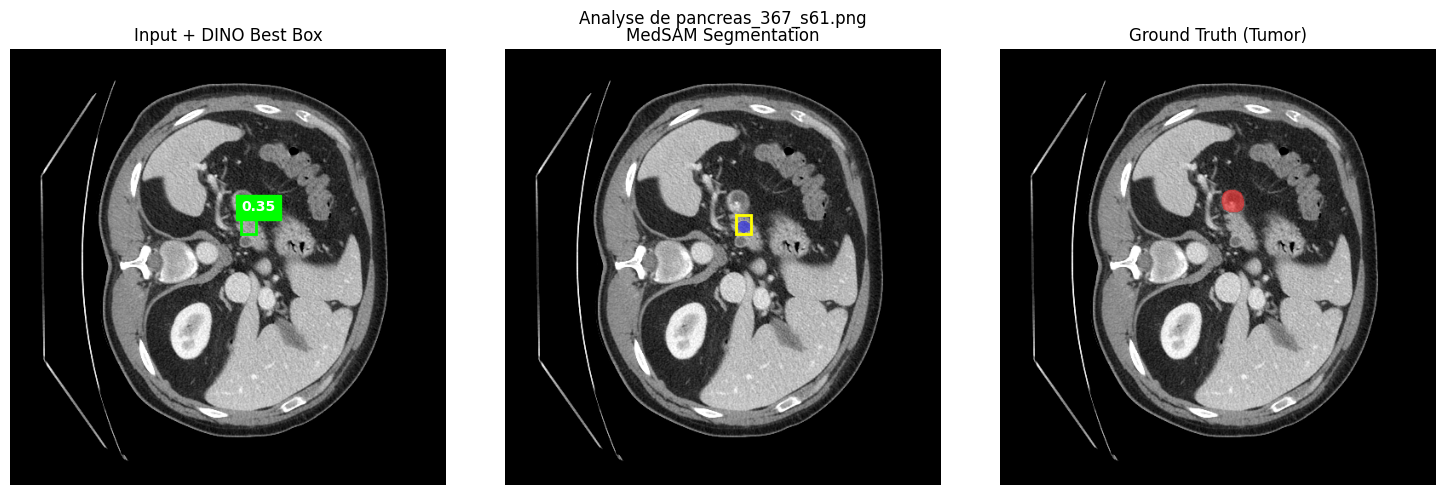

In [17]:
import os
import json
import random
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io, transform
from PIL import Image

# Imports Grounding DINO
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules

# Imports MedSAM
from MedSAM.segment_anything import sam_model_registry
from MedSAM.MedSAM_Inference import medsam_inference

# ==========================================
# FONCTIONS UTILITAIRES D'AFFICHAGE
# ==========================================
def show_mask(mask, ax, color=(1, 0, 0, 0.5)):
    """Affiche un masque binaire avec une couleur et une transparence (alpha)."""
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, edgecolor='lime', label=None):
    """Affiche une bounding box au format [xmin, ymin, xmax, ymax]."""
    x_min, y_min, x_max, y_max = box
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor=edgecolor, facecolor='none'
    )
    ax.add_patch(rect)
    if label:
        ax.text(x_min, y_min - 5, label, color='white', 
                backgroundcolor=edgecolor, fontsize=10, fontweight='bold')

# ==========================================
# 1. INITIALISATION DES MODÈLES
# ==========================================
register_all_modules()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Appareil détecté : {device}")

# Modèle DINO
config_file = "tumor_config_v3.py"
checkpoint_file = "work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth"
dino_model = init_detector(config_file, checkpoint_file, device=device)

# Modèle MedSAM
medsam_checkpoint = "MedSAM/work_dir/MedSAM/medsam_vit_b.pth"
medsam_model = sam_model_registry["vit_b"](checkpoint=medsam_checkpoint)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# ==========================================
# 2. FONCTION PRINCIPALE DE VISUALISATION
# ==========================================
def visualize_pipeline_msd(image_path, text_prompt="tumor."):
    if not text_prompt.endswith('.'):
        text_prompt += '.'

    img_np = io.imread(image_path)
    if len(img_np.shape) == 2:
        img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
    else:
        img_3c = img_np
    H, W, _ = img_3c.shape

    # Chargement du masque Ground Truth (MSD = remplacer images par masks)
    mask_path = image_path.replace("/images/", "/masks/")
    true_seg = np.zeros((H, W), dtype=np.uint8)
    if os.path.exists(mask_path):
        true_seg_raw = io.imread(mask_path)
        true_seg[true_seg_raw == 2] = 1 # 2 correspond à la tumeur

    # A. Inférence Grounding DINO
    result = inference_detector(dino_model, image_path, text_prompt=text_prompt)
    pred_instances = result.pred_instances
    scores = pred_instances.scores.cpu().numpy()
    bboxes = pred_instances.bboxes.cpu().numpy()
    
    mask_conf = scores > 0.1 # Seuil de confiance
    valid_boxes = bboxes[mask_conf]
    valid_scores = scores[mask_conf]

    medsam_seg = np.zeros((H, W), dtype=np.uint8)
    best_box = None
    best_score = 0

    # B. Inférence MedSAM (si une boîte est trouvée)
    if len(valid_boxes) > 0:
        best_idx = np.argmax(valid_scores)
        best_box = valid_boxes[best_idx]
        best_score = valid_scores[best_idx]
        
        with torch.no_grad():
            img_1024 = transform.resize(img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
            img_1024 = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None)
            img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)
            
            image_embedding = medsam_model.image_encoder(img_1024_tensor)
            
            box_np = np.array([best_box]) 
            box_1024 = box_np / np.array([W, H, W, H]) * 1024
            
            pred_mask = medsam_inference(medsam_model, image_embedding, box_1024, H, W)
            medsam_seg[pred_mask > 0] = 1

    # C. Affichage Matplotlib
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Input + DINO Box
    ax[0].imshow(img_3c)
    if best_box is not None:
        show_box(best_box, ax[0], label=f"{best_score:.2f}")
    ax[0].set_title("Input + DINO Best Box")
    ax[0].axis('off')

    # Panel 2: Input + MedSAM Seg + DINO Box
    ax[1].imshow(img_3c)
    if best_box is not None:
        show_box(best_box, ax[1], edgecolor='yellow')
    show_mask(medsam_seg, ax[1], color=(0, 0, 1, 0.5)) # Bleu translucide
    ax[1].set_title("MedSAM Segmentation")
    ax[1].axis('off')

    # Panel 3: Input + Ground Truth
    ax[2].imshow(img_3c)
    show_mask(true_seg, ax[2], color=(1, 0, 0, 0.5)) # Rouge translucide
    ax[2].set_title("Ground Truth (Tumor)")
    ax[2].axis('off')

    plt.suptitle(f"Analyse de {os.path.basename(image_path)}")
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. LANCEMENT DU TEST
# ==========================================
img_dir = "data/MSD_pancreas/test/images" # On pointe vers le dossier de test
image_paths = glob.glob(os.path.join(img_dir, "*.png"))

if image_paths:
    random_image = random.choice(image_paths)
    print(f"Évaluation de l'image : {random_image}")
    visualize_pipeline_msd(random_image)

Appareil detecte : cuda


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loads checkpoint by local backend from path: work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_25.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

noun_phrases: ['pancreas', 'tumor']


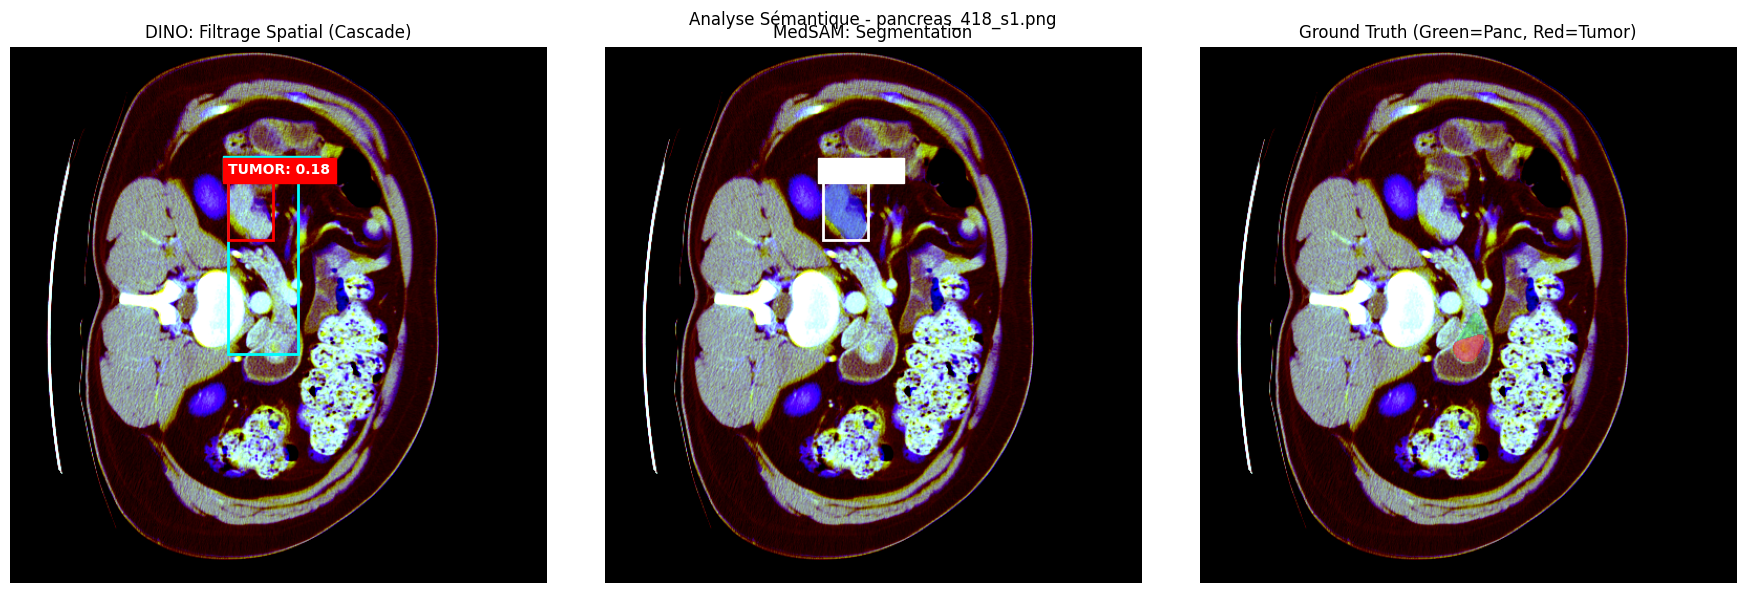

In [8]:
import os
import json
import random
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io, transform

# Imports Grounding DINO
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules

# Imports MedSAM
from MedSAM.segment_anything import sam_model_registry
from MedSAM.MedSAM_Inference import medsam_inference

# ==========================================
# FONCTIONS UTILITAIRES D'AFFICHAGE
# ==========================================
def show_mask(mask, ax, color=(1, 0, 0, 0.5)):
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, edgecolor='lime', label=None):
    x_min, y_min, x_max, y_max = box
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor=edgecolor, facecolor='none'
    )
    ax.add_patch(rect)
    if label:
        ax.text(x_min, y_min - 5, label, color='white', 
                backgroundcolor=edgecolor, fontsize=10, fontweight='bold')

# ==========================================
# 1. INITIALISATION DES MODÈLES
# ==========================================
register_all_modules()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Appareil detecte : {device}")

# Modèle DINO (À adapter selon ton meilleur checkpoint)
config_file = "tumor_config_v3.py" 
checkpoint_file = "work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_25.pth" 
dino_model = init_detector(config_file, checkpoint_file, device=device)

# Modèle MedSAM
medsam_checkpoint = "MedSAM/work_dir/MedSAM/medsam_vit_b.pth"
medsam_model = sam_model_registry["vit_b"](checkpoint=medsam_checkpoint)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# ==========================================
# 2. FONCTION DE VISUALISATION COMPARATIVE
# ==========================================
def analyze_pipeline_predictions(image_path):
    # Traitement 2.5D pour préserver le contraste
    img_np = io.imread(image_path)
    if len(img_np.shape) == 2:
        img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
    else:
        img_3c = img_np
    H, W, _ = img_3c.shape

    # Chargement GT : 1=Pancréas, 2=Tumeur
    mask_path = image_path.replace("/images/", "/masks/")
    true_tumor = np.zeros((H, W), dtype=np.uint8)
    true_pancreas = np.zeros((H, W), dtype=np.uint8)
    if os.path.exists(mask_path):
        gt = io.imread(mask_path)
        true_tumor[gt == 2] = 1
        true_pancreas[gt == 1] = 1

    # Inférence DINO avec Prompt Unifié
    with torch.no_grad():
        result = inference_detector(dino_model, image_path, text_prompt="pancreas . tumor .")
        pred = result.pred_instances
        
        scores = pred.scores.cpu().numpy()
        bboxes = pred.bboxes.cpu().numpy()
        labels = pred.labels.cpu().numpy()

        # Application des seuils asymétriques
        pancreas_mask = (labels == 0) & (scores > 0.3)
        tumor_mask = (labels == 1) & (scores > 0.01) 
        
        pancreas_boxes = bboxes[pancreas_mask]
        pancreas_scores = scores[pancreas_mask]
        tumor_boxes = bboxes[tumor_mask]
        tumor_scores = scores[tumor_mask]

        best_panc_box = None
        best_panc_score = 0.0
        best_tumor_box = None
        best_tumor_score = 0.0

        # CASCADE LOGIQUE SPATIALE
        if len(pancreas_boxes) > 0:
            best_panc_idx = np.argmax(pancreas_scores)
            best_panc_box = pancreas_boxes[best_panc_idx]
            best_panc_score = float(pancreas_scores[best_panc_idx])
            p_x1, p_y1, p_x2, p_y2 = best_panc_box
            
            margin = 20
            p_x1, p_y1 = max(0, p_x1 - margin), max(0, p_y1 - margin)
            p_x2, p_y2 = p_x2 + margin, p_y2 + margin

            valid_tumor_boxes = []
            valid_tumor_scores = []
            
            for t_box, t_score in zip(tumor_boxes, tumor_scores):
                t_cx = (t_box[0] + t_box[2]) / 2
                t_cy = (t_box[1] + t_box[3]) / 2
                if (p_x1 <= t_cx <= p_x2) and (p_y1 <= t_cy <= p_y2):
                    valid_tumor_boxes.append(t_box)
                    valid_tumor_scores.append(t_score)
            
            if valid_tumor_boxes:
                best_idx = np.argmax(valid_tumor_scores)
                best_tumor_box = valid_tumor_boxes[best_idx]
                best_tumor_score = float(valid_tumor_scores[best_idx])
                
        elif len(pancreas_boxes) == 0 and len(tumor_boxes) > 0:
            best_idx = np.argmax(tumor_scores)
            best_tumor_box = tumor_boxes[best_idx]
            best_tumor_score = float(tumor_scores[best_idx])

    # Inférence MedSAM sur la boîte retenue
    medsam_seg = np.zeros((H, W), dtype=np.uint8)
    if best_tumor_box is not None:
        with torch.no_grad():
            img_1024 = transform.resize(img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
            img_1024 = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None)
            img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)
            
            image_embedding = medsam_model.image_encoder(img_1024_tensor)
            box_1024 = best_tumor_box / np.array([W, H, W, H]) * 1024
            
            pred_mask = medsam_inference(medsam_model, image_embedding, np.array([box_1024]), H, W)
            medsam_seg[pred_mask > 0] = 1

    # AFFICHAGE
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Panel 1: Détections DINO (Cascade passée)
    ax[0].imshow(img_3c)
    if best_panc_box is not None:
        show_box(best_panc_box, ax[0], edgecolor='cyan', label=f"PANC: {best_panc_score:.2f}")
    if best_tumor_box is not None:
        show_box(best_tumor_box, ax[0], edgecolor='red', label=f"TUMOR: {best_tumor_score:.2f}")
    ax[0].set_title("DINO: Filtrage Spatial (Cascade)")
    ax[0].axis('off')

    # Panel 2: Résultat MedSAM
    ax[1].imshow(img_3c)
    show_mask(medsam_seg, ax[1], color=(0, 0, 1, 0.4))
    if best_tumor_box is not None:
        show_box(best_tumor_box, ax[1], edgecolor='white', label="Input Box")
    ax[1].set_title("MedSAM: Segmentation")
    ax[1].axis('off')

    # Panel 3: Vérité terrain
    ax[2].imshow(img_3c)
    show_mask(true_pancreas, ax[2], color=(0, 1, 0, 0.3))
    show_mask(true_tumor, ax[2], color=(1, 0, 0, 0.5))
    ax[2].set_title("Ground Truth (Green=Panc, Red=Tumor)")
    ax[2].axis('off')

    plt.suptitle(f"Analyse Sémantique - {os.path.basename(image_path)}")
    plt.tight_layout()
    plt.show()

# # ==========================================
# # 3. TEST SUR IMAGES ALÉATOIRES
# # ==========================================
# img_dir = "data/MSD_pancreas/images" 
# image_paths = glob.glob(os.path.join(img_dir, "*.png"))

# if image_paths:
#     for _ in range(3):
#         random_image = random.choice(image_paths)
#         analyze_pipeline_predictions(random_image)

analyze_pipeline_predictions("data/MSD_pancreas/test/images/pancreas_418_s1.png")

/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Appareil detecte : cuda


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loads checkpoint by local backend from path: work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_25.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

noun_phrases: ['pancreas', 'tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


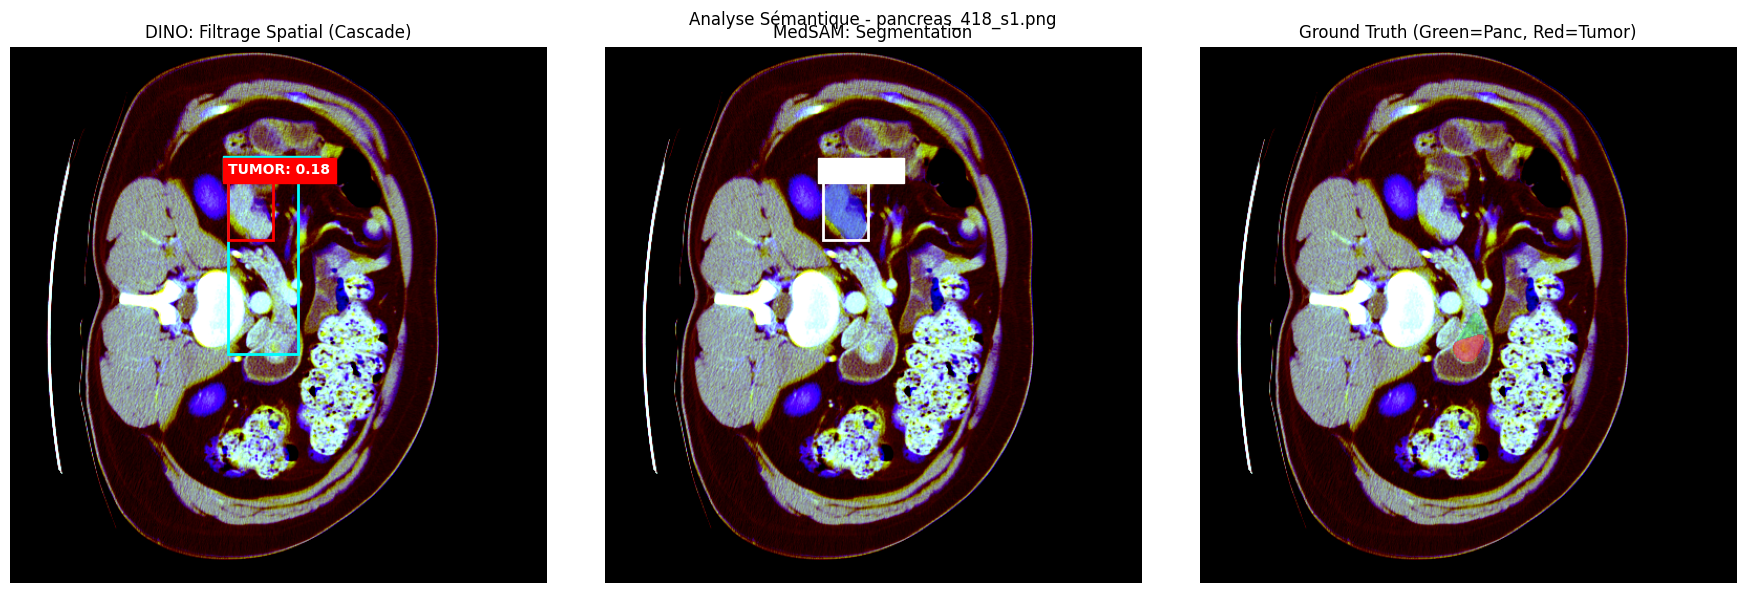

In [1]:
import os
import json
import random
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io, transform

# Imports Grounding DINO
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules

# Imports MedSAM
from MedSAM.segment_anything import sam_model_registry
from MedSAM.MedSAM_Inference import medsam_inference

# ==========================================
# FONCTIONS UTILITAIRES D'AFFICHAGE
# ==========================================
def show_mask(mask, ax, color=(1, 0, 0, 0.5)):
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, edgecolor='lime', label=None):
    x_min, y_min, x_max, y_max = box
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor=edgecolor, facecolor='none'
    )
    ax.add_patch(rect)
    if label:
        ax.text(x_min, y_min - 5, label, color='white', 
                backgroundcolor=edgecolor, fontsize=10, fontweight='bold')

# ==========================================
# 1. INITIALISATION DES MODÈLES
# ==========================================
register_all_modules()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Appareil detecte : {device}")

# Modèle DINO (À adapter selon ton meilleur checkpoint)
config_file = "tumor_config_v3.py" 
checkpoint_file = "work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_25.pth" 
dino_model = init_detector(config_file, checkpoint_file, device=device)

# Modèle MedSAM
medsam_checkpoint = "MedSAM/work_dir/MedSAM/medsam_vit_b.pth"
medsam_model = sam_model_registry["vit_b"](checkpoint=medsam_checkpoint)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# ==========================================
# 2. FONCTION DE VISUALISATION COMPARATIVE
# ==========================================
def analyze_pipeline_predictions(image_path):
    # Traitement 2.5D pour préserver le contraste
    img_np = io.imread(image_path)
    if len(img_np.shape) == 2:
        img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
    else:
        img_3c = img_np
    H, W, _ = img_3c.shape

    # Chargement GT : 1=Pancréas, 2=Tumeur
    mask_path = image_path.replace("/images/", "/masks/")
    true_tumor = np.zeros((H, W), dtype=np.uint8)
    true_pancreas = np.zeros((H, W), dtype=np.uint8)
    if os.path.exists(mask_path):
        gt = io.imread(mask_path)
        true_tumor[gt == 2] = 1
        true_pancreas[gt == 1] = 1

    # Inférence DINO avec Prompt Unifié
    with torch.no_grad():
        result = inference_detector(dino_model, image_path, text_prompt="pancreas . tumor .")
        pred = result.pred_instances
        
        scores = pred.scores.cpu().numpy()
        bboxes = pred.bboxes.cpu().numpy()
        labels = pred.labels.cpu().numpy()

        # Application des seuils asymétriques
        pancreas_mask = (labels == 0) & (scores > 0.3)
        tumor_mask = (labels == 1) & (scores > 0.01) 
        
        pancreas_boxes = bboxes[pancreas_mask]
        pancreas_scores = scores[pancreas_mask]
        tumor_boxes = bboxes[tumor_mask]
        tumor_scores = scores[tumor_mask]

        best_panc_box = None
        best_panc_score = 0.0
        best_tumor_box = None
        best_tumor_score = 0.0

        # CASCADE LOGIQUE SPATIALE AVEC OVERLAP
        if len(pancreas_boxes) > 0:
            best_panc_idx = np.argmax(pancreas_scores)
            best_panc_box = pancreas_boxes[best_panc_idx]
            best_panc_score = float(pancreas_scores[best_panc_idx])
            p_x1, p_y1, p_x2, p_y2 = best_panc_box
            
            margin = 20
            p_x1, p_y1 = max(0, p_x1 - margin), max(0, p_y1 - margin)
            p_x2, p_y2 = p_x2 + margin, p_y2 + margin

            valid_tumor_boxes = []
            valid_tumor_scores = []
            
            for t_box, t_score in zip(tumor_boxes, tumor_scores):
                t_x1, t_y1, t_x2, t_y2 = t_box
                
                # Calcul de l'intersection
                inter_x1 = max(t_x1, p_x1)
                inter_y1 = max(t_y1, p_y1)
                inter_x2 = min(t_x2, p_x2)
                inter_y2 = min(t_y2, p_y2)
                
                # Vérification de la validité de l'intersection
                if inter_x2 > inter_x1 and inter_y2 > inter_y1:
                    intersection_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
                    tumor_area = (t_x2 - t_x1) * (t_y2 - t_y1)
                    
                    overlap_ratio = intersection_area / tumor_area
                    
                    # Si au moins 10% de la tumeur chevauche la zone du pancréas
                    if overlap_ratio >= 0.1:
                        valid_tumor_boxes.append(t_box)
                        valid_tumor_scores.append(t_score)
            
            if valid_tumor_boxes:
                best_idx = np.argmax(valid_tumor_scores)
                best_tumor_box = valid_tumor_boxes[best_idx]
                best_tumor_score = float(valid_tumor_scores[best_idx])
                
        elif len(pancreas_boxes) == 0 and len(tumor_boxes) > 0:
            best_idx = np.argmax(tumor_scores)
            best_tumor_box = tumor_boxes[best_idx]
            best_tumor_score = float(tumor_scores[best_idx])

    # Inférence MedSAM sur la boîte retenue
    medsam_seg = np.zeros((H, W), dtype=np.uint8)
    if best_tumor_box is not None:
        with torch.no_grad():
            img_1024 = transform.resize(img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
            img_1024 = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None)
            img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)
            
            image_embedding = medsam_model.image_encoder(img_1024_tensor)
            box_1024 = best_tumor_box / np.array([W, H, W, H]) * 1024
            
            pred_mask = medsam_inference(medsam_model, image_embedding, np.array([box_1024]), H, W)
            medsam_seg[pred_mask > 0] = 1

    # AFFICHAGE
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Panel 1: Détections DINO (Cascade passée)
    ax[0].imshow(img_3c)
    if best_panc_box is not None:
        show_box(best_panc_box, ax[0], edgecolor='cyan', label=f"PANC: {best_panc_score:.2f}")
    if best_tumor_box is not None:
        show_box(best_tumor_box, ax[0], edgecolor='red', label=f"TUMOR: {best_tumor_score:.2f}")
    ax[0].set_title("DINO: Filtrage Spatial (Cascade)")
    ax[0].axis('off')

    # Panel 2: Résultat MedSAM
    ax[1].imshow(img_3c)
    show_mask(medsam_seg, ax[1], color=(0, 0, 1, 0.4))
    if best_tumor_box is not None:
        show_box(best_tumor_box, ax[1], edgecolor='white', label="Input Box")
    ax[1].set_title("MedSAM: Segmentation")
    ax[1].axis('off')

    # Panel 3: Vérité terrain
    ax[2].imshow(img_3c)
    show_mask(true_pancreas, ax[2], color=(0, 1, 0, 0.3))
    show_mask(true_tumor, ax[2], color=(1, 0, 0, 0.5))
    ax[2].set_title("Ground Truth (Green=Panc, Red=Tumor)")
    ax[2].axis('off')

    plt.suptitle(f"Analyse Sémantique - {os.path.basename(image_path)}")
    plt.tight_layout()
    plt.show()

# Test direct sur l'image problématique ciblée
analyze_pipeline_predictions("data/MSD_pancreas/test/images/pancreas_418_s1.png")